In [1]:
#import radvel
import numpy as np
import pandas as pd
import lightkurve as lk
#import astropy.io.fits as pf
from astropy.io import fits
from glob import glob as glob
import matplotlib.pyplot as plt

In [2]:
TIC =  'TIC 4672985 b'
#searching SPOC data is available for a given target - and chose a sector
sector_data = lk.search_lightcurve(TIC) #author = 'TESS-SPOC', you can use this as well

In [3]:
sector_data

#,mission,year,author,exptime,target_name,distance
,,,,s,,arcsec
0,TESS Sector 31,2020,SPOC,20,4672985,0.0
1,TESS Sector 31,2020,SPOC,120,4672985,0.0
2,TESS Sector 04,2018,TESS-SPOC,1800,4672985,0.0
3,TESS Sector 31,2020,TESS-SPOC,600,4672985,0.0
4,TESS Sector 04,2018,QLP,1800,4672985,0.0
5,TESS Sector 31,2020,QLP,600,4672985,0.0
6,TESS Sector 04,2018,GSFC-ELEANOR-LITE,1800,4672985,0.0
7,TESS Sector 04,2018,TASOC,1800,4672985,0.0
8,TESS Sector 04,2018,TASOC,1800,4672985,0.0


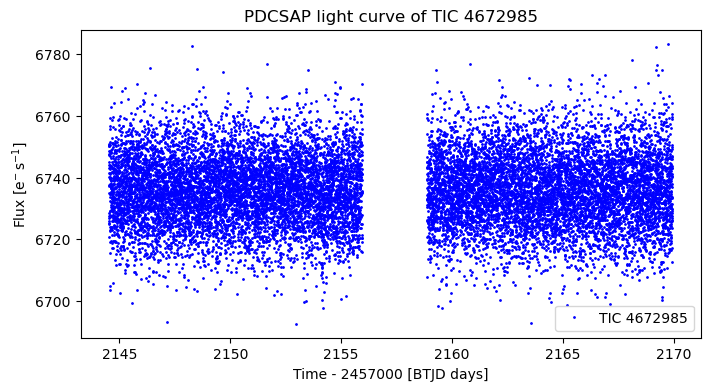

In [4]:
lc = sector_data[1].download() #since, more exposure time
fig, ax = plt.subplots(figsize = (8,4))
lc.plot(ax = ax, lw = 0, marker = '.', color = 'blue', label = 'TIC 4672985')
ax.set_title("PDCSAP light curve of TIC 4672985")
plt.legend()

In [5]:
#period and epoch time (where there is empty spot in above graph , roughly) should be taken for below

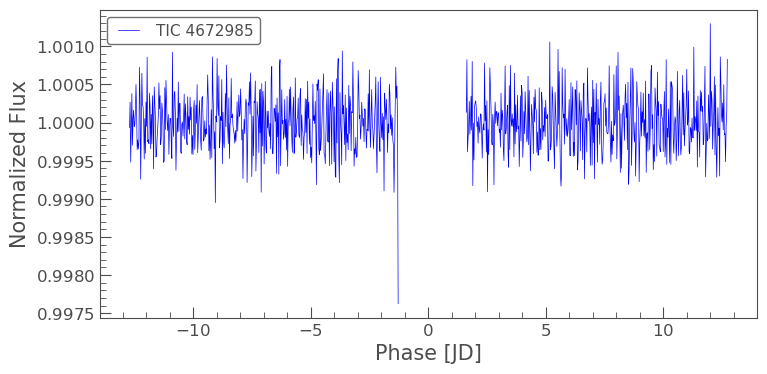

In [6]:
#fold and bin our data to look at the transit
lc.remove_nans().flatten(window_length=401).fold(period=69.0480,  epoch_time=2157.2344053608995).bin(time_bin_size=0.025).plot(color = 'blue');

In [6]:
#the time format is the unit of time, in this case Barycentric Kepler Julian Date (BKJD)

In [5]:
lc.meta

{'INHERIT': True,
 'EXTNAME': 'PRIMARY',
 'EXTVER': 1,
 'SIMDATA': False,
 'TELESCOP': 'TESS',
 'INSTRUME': 'TESS Photometer',
 'OBJECT': 'TIC 4672985',
 'TICID': 4672985,
 'RADESYS': 'ICRS',
 'RA_OBJ': 38.470488828483,
 'DEC_OBJ': -10.6572632518315,
 'EQUINOX': 2000.0,
 'EXPOSURE': 20.140670312066,
 'TIMEREF': 'SOLARSYSTEM',
 'TASSIGN': 'SPACECRAFT',
 'TIMESYS': 'TDB',
 'BJDREFI': 2457000,
 'BJDREFF': 0.0,
 'TIMEUNIT': 'd',
 'TELAPSE': 25.430139282912,
 'LIVETIME': 20.140670312066323,
 'TSTART': 2144.519335835184,
 'TSTOP': 2169.949474886615,
 'DATE-OBS': '2020-10-22T00:26:41.432',
 'DATE-END': '2020-11-16T10:46:05.446',
 'DEADC': 0.792,
 'TIMEPIXR': 0.5,
 'TIERRELA': 1.16e-05,
 'INT_TIME': 1.98,
 'READTIME': 0.02,
 'FRAMETIM': 2.0,
 'NUM_FRM': 60,
 'TIMEDEL': 0.001388888888888889,
 'BACKAPP': True,
 'DEADAPP': True,
 'VIGNAPP': True,
 'GAINA': 5.21999979019165,
 'GAINB': 5.210000038146973,
 'GAINC': 5.210000038146973,
 'GAIND': 5.260000228881836,
 'READNOIA': 10.022398948669434,
 'RE

In [7]:
a = lc.meta['TSTART'] + lc.meta['TSTOP']
a/2 #use this for epoch time

2157.2344053608995

In [8]:
star = fits.open('ADP.2021-02-06T01_11_34.744.fits')
star
data = star[1].data

In [9]:
data.columns

ColDefs(
    name = 'WAVE'; format = '313057D'; unit = 'angstrom'
    name = 'FLUX'; format = '313057E'; unit = 'adu'
    name = 'ERR'; format = '313057E'; unit = 'adu'
)

In [10]:
#adu is analog to digital scale and for intensity it is called counts

In [11]:
# Extract data arrays
wavelength = data['WAVE'][0]
flux = data['FLUX'][0]
error = data['ERR'][0]

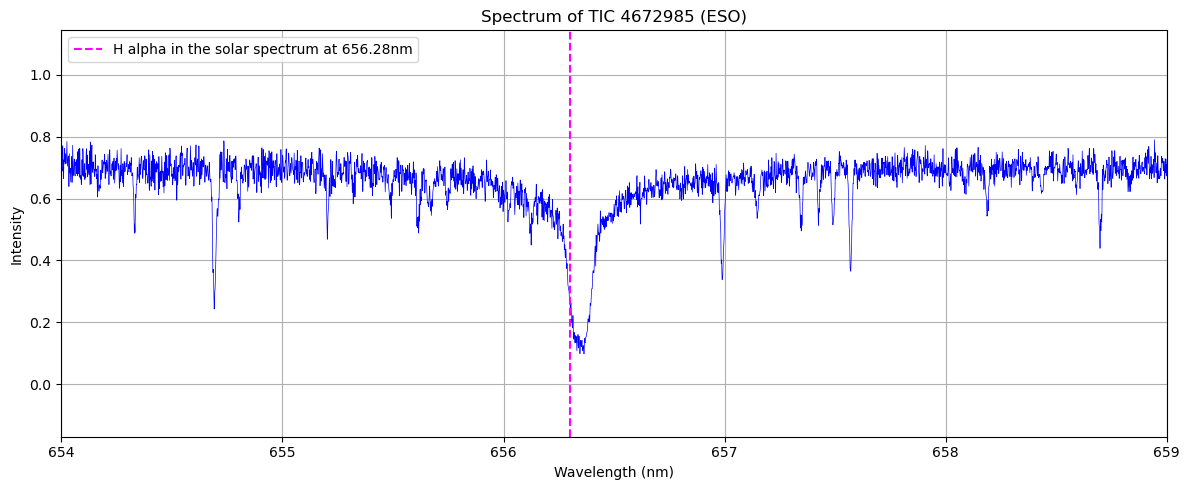

In [ ]:
# Plot the spectrum
plt.figure(figsize=(12, 5))
plt.plot(wavelength/10, flux/1000 , color='blue', lw=0.5) #flux is divided by 1000 to make it from 0 to 1, put: label='Flux', if required
#wavelength by 10 is done to change angstrom values to nanometers
plt.xlim(654, 659)

plt.axvline(656.3, color = 'magenta', linestyle = '--', label = 'H alpha in the solar spectrum at 656.28nm')
plt.xlabel('Wavelength (nm)')
plt.ylabel('Intensity')
plt.title('Spectrum of TIC 4672985 (ESO)')
plt.grid(True)
plt.legend(loc = 'upper left')
plt.tight_layout()
plt.show()

#Optional: to plot the error as a shaded region
#plt.fill_between(wavelength, flux - error, flux + error, color='gray', alpha=0.3, label='Error')


In [15]:
#it shows a lot of different absorption lines, light from star, diff stars have diff absorption lines, 

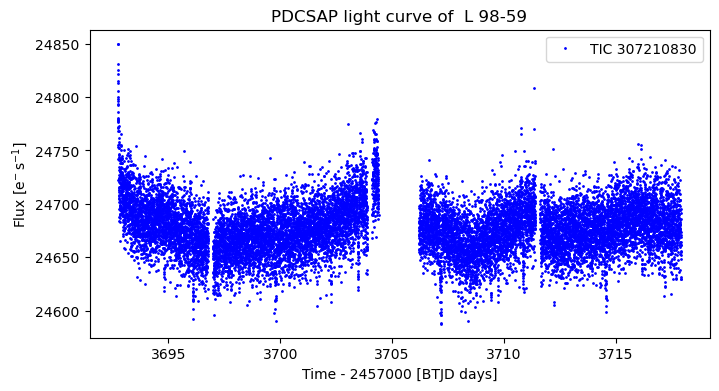

In [29]:
req = lk.search_lightcurve('TIC 307210830 c', author= 'SPOC', exptime= 120, sector= 88)
lcf = req.download()
fig, ax = plt.subplots(figsize = (8,4))
lcf.plot(ax = ax, lw = 0, marker = '.', color = 'blue', label = 'TIC 307210830')
ax.set_title("PDCSAP light curve of  L 98-59")
plt.legend()
#lcf.plot()
#lcf.meta
#lcf.remove_nans().flatten(window_length=401).fold(period=3.690621,  epoch_time=1367.2755).bin(time_bin_size=0.025).plot();

<Axes: xlabel='Time - 2457000 [BTJD days]', ylabel='Flux [$\\mathrm{e^{-}\\,s^{-1}}$]'>

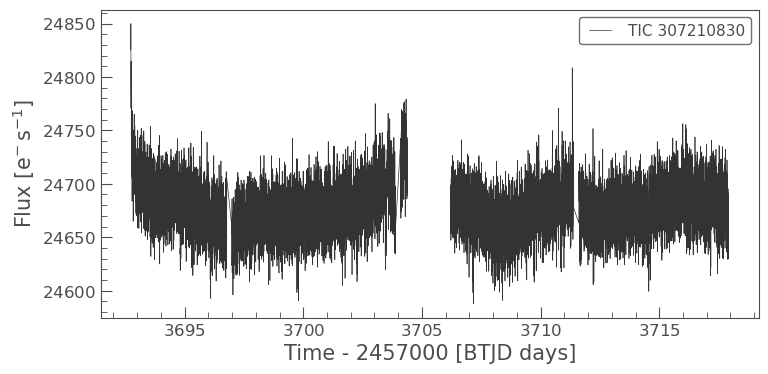

In [17]:
lcf.plot()

In [18]:
lcf.meta

{'INHERIT': True,
 'EXTNAME': 'PRIMARY',
 'EXTVER': 1,
 'SIMDATA': False,
 'TELESCOP': 'TESS',
 'INSTRUME': 'TESS Photometer',
 'OBJECT': 'TIC 307210830',
 'TICID': 307210830,
 'RADESYS': 'ICRS',
 'RA_OBJ': 124.531756290083,
 'DEC_OBJ': -68.3129998725044,
 'EQUINOX': 2000.0,
 'EXPOSURE': 21.996074157273,
 'TIMEREF': 'SOLARSYSTEM',
 'TASSIGN': 'SPACECRAFT',
 'TIMESYS': 'TDB',
 'BJDREFI': 2457000,
 'BJDREFF': 0.0,
 'TIMEUNIT': 'd',
 'TELAPSE': 27.772820905647,
 'LIVETIME': 21.996074157272602,
 'TSTART': 3690.151885218606,
 'TSTOP': 3717.924705892771,
 'DATE-OBS': '2025-01-14T15:37:33.699',
 'DATE-END': '2025-02-11T10:10:25.405',
 'DEADC': 0.792,
 'TIMEPIXR': 0.5,
 'TIERRELA': 1.16e-05,
 'INT_TIME': 1.98,
 'READTIME': 0.02,
 'FRAMETIM': 2.0,
 'NUM_FRM': 60,
 'TIMEDEL': 0.0013888888888889,
 'BACKAPP': True,
 'DEADAPP': True,
 'VIGNAPP': True,
 'GAINA': 5.260000228881836,
 'GAINB': 5.179999828338623,
 'GAINC': 5.199999809265137,
 'GAIND': 5.199999809265137,
 'READNOIA': 10.046600341796875,


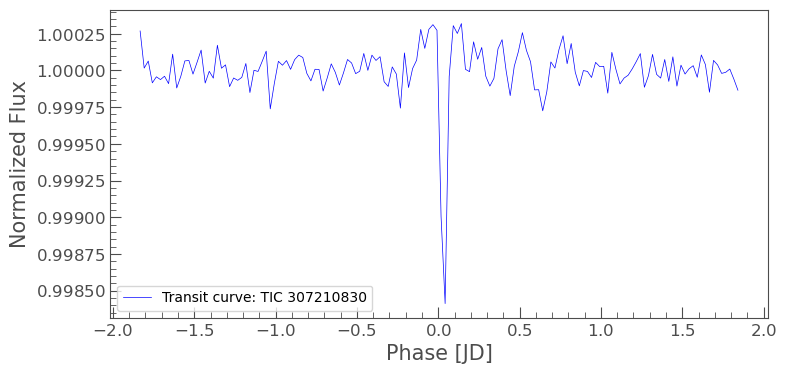

In [30]:
lcf.remove_nans().flatten(window_length=401).fold(period=3.690621,  epoch_time=1367.2755).bin(time_bin_size=0.025).plot(color = 'blue', label = 'Transit curve: TIC 307210830');
plt.legend()

In [20]:
search = lk.search_targetpixelfile('TIC 307210830 c' , author= 'SPOC', exptime= 120, sector= 88)
search

#,mission,year,author,exptime,target_name,distance
,,,,s,,arcsec
0,TESS Sector 88,2025,SPOC,120,307210830,0.0


In [21]:
tpf = lk.search_targetpixelfile('TIC 307210830 c' , author= 'SPOC', exptime= 120, sector= 88).download()
tpf

TessTargetPixelFile(TICID: 307210830)

In [22]:
target = tpf.to_lightcurve(aperture_mask=tpf.pipeline_mask)
target

time,flux,flux_err,centroid_col,centroid_row,cadenceno,quality
,electron / s,electron / s,pix,pix,,
Time,float32,float32,float64,float64,int32,int32
3690.1525795633897,23182.521484375,17.462379455566406,74.00199789114878,1207.1814321246106,1773142,32768
3690.1539684844383,23208.84765625,17.474933624267578,74.00443885321477,1207.1945361667824,1773143,32768
3690.1553574054888,23198.794921875,17.471723556518555,74.00587843648674,1207.1823356155774,1773144,32768
3690.156746326542,23177.4921875,17.467082977294922,74.00792977990533,1207.1972851604041,1773145,32768
3690.1581352475946,23170.302734375,17.472726821899414,74.00006158688174,1207.1860086098354,1773146,32768
3690.159524168645,23193.095703125,17.48113441467285,74.00388634977377,1207.1917132145095,1773147,32768
3690.160913089719,23182.166015625,17.4797306060791,73.99574176927513,1207.1741122667352,1773148,32768
3690.162302010799,23220.5234375,17.492218017578125,74.01022834030468,1207.204383712145,1773149,32768


<Axes: xlabel='Time - 2457000 [BTJD days]', ylabel='Flux [$\\mathrm{e^{-}\\,s^{-1}}$]'>

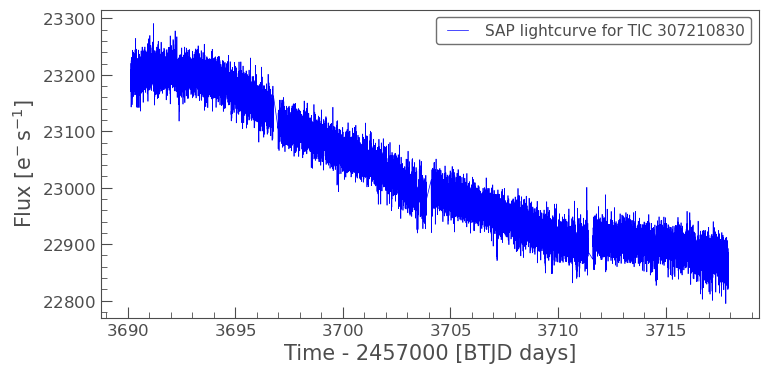

In [23]:
target.plot(color = 'blue', label = 'SAP lightcurve for TIC 307210830')

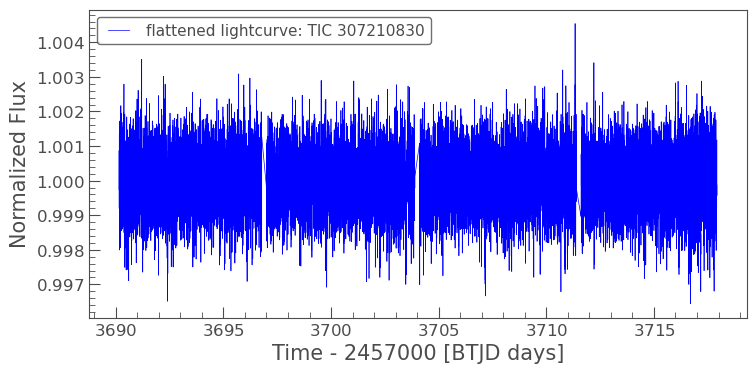

In [31]:
flat_lc = target.flatten(window_length=401)
flat_lc.plot(color = 'blue', label = 'flattened lightcurve: TIC 307210830');

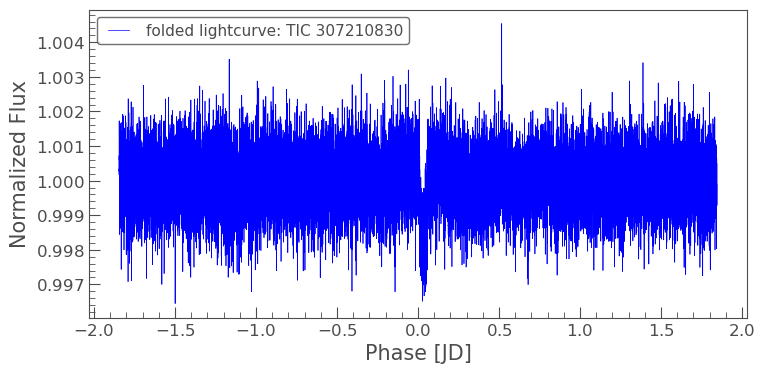

In [32]:
folded_lc = flat_lc.fold(period=3.690621,  epoch_time=1367.2755)
folded_lc.plot(color = 'blue', label = 'folded lightcurve: TIC 307210830');

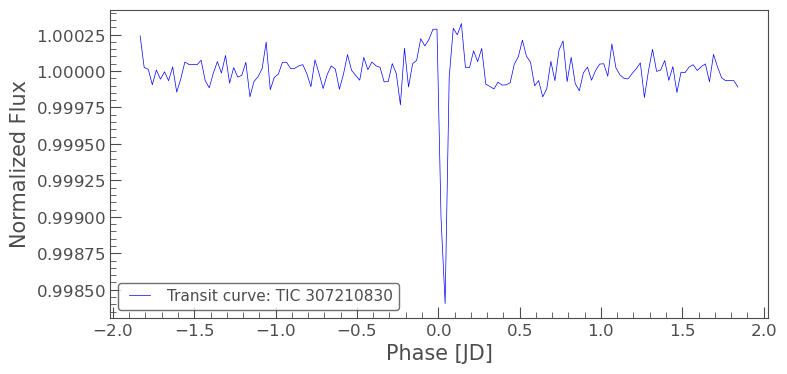

In [33]:
target.remove_nans().flatten(window_length=401).fold(period=3.690621,  epoch_time=1367.2755).bin(time_bin_size=0.025).plot(color = 'blue', label = 'Transit curve: TIC 307210830');

In [51]:
search_list = lk.search_targetpixelfile(TIC, exptime = 120)
tpf = lk.search_targetpixelfile(TIC, exptime = 120).download()
target = tpf.to_lightcurve(aperture_mask=tpf.pipeline_mask)

In [56]:
search_list

#,mission,year,author,exptime,target_name,distance
,,,,s,,arcsec
0,TESS Sector 31,2020,SPOC,120,4672985,0.0


<Axes: xlabel='Time - 2457000 [BTJD days]', ylabel='Flux [$\\mathrm{e^{-}\\,s^{-1}}$]'>

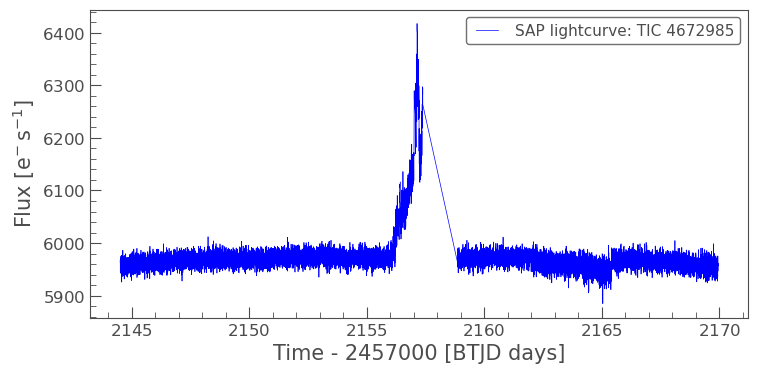

In [52]:
target.plot(color = 'blue', label = 'SAP lightcurve: TIC 4672985')

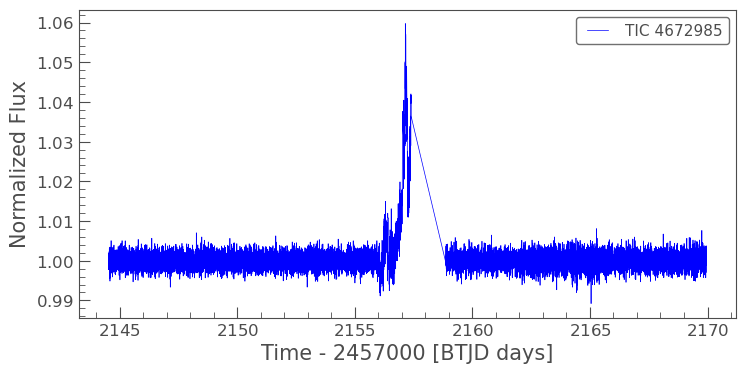

In [53]:
flat_lc = target.flatten(window_length=401)
flat_lc.plot(color = 'blue');

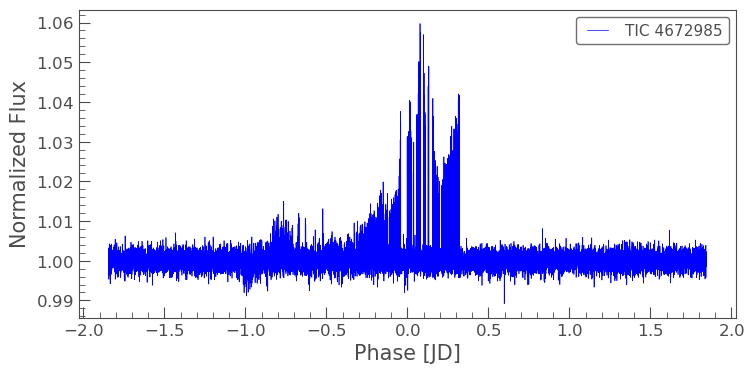

In [54]:
folded_lc = flat_lc.fold(period=3.690621,  epoch_time=1367.2755)
folded_lc.plot(color = 'blue');

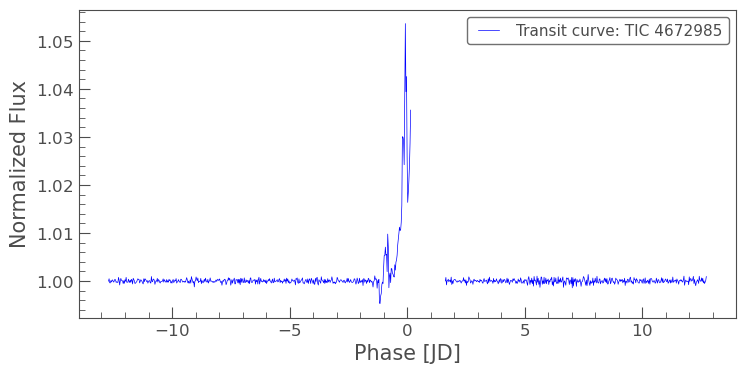

In [58]:
target.remove_nans().flatten(window_length=401).fold(period=69.0480,  epoch_time=2157.2344053608995).bin(time_bin_size=0.025).plot(color = 'blue', label = 'Transit curve: TIC 4672985');